In [5]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
peak_bed_file = "Rv0047c_chip.bed"
deg_csv_file = "KOvsWT_supo_DEG_limma(1).csv"
gtf_file = "H37Rv.gtf"

out_csv_file = "deg_peak_annotated.csv"
out_png_file = "four_quadrant_volcano.png"

In [61]:
def read_peak_bed(bed_file):
    peak_df = pd.read_csv(
        bed_file,
        sep="\t",
        header=None,
        comment="#"
    )

    if peak_df.shape[1] < 3:
        raise ValueError("BED 文件至少需要 3 列: chrom, start, end")

    peak_df = peak_df.iloc[:, :3].copy()
    peak_df.columns = ["chrom", "start", "end"]
    peak_df["start"] = peak_df["start"].astype(int)
    peak_df["end"] = peak_df["end"].astype(int)

    return peak_df


def parse_gtf_attributes(attr_str):
    """
    兼容两种格式：

    1. 标准 GTF:
       gene_id "Rv0001"; gene_name "dnaA";

    2. 你的格式:
       "gene_id ""Rv0001""; gene_name ""dnaA""; gene_source ""ena"";"
    """
    if pd.isna(attr_str):
        return {}

    s = str(attr_str).strip()

    # 去掉最外层引号
    if len(s) >= 2 and s[0] == '"' and s[-1] == '"':
        s = s[1:-1]

    attrs = {}

    # 先匹配双双引号格式
    pattern1 = re.findall(r'(\S+)\s+""([^"]+)""', s)
    for key, value in pattern1:
        attrs[key] = value

    # 若没匹配到，再匹配普通格式
    if not attrs:
        pattern2 = re.findall(r'(\S+)\s+"([^"]+)"', s)
        for key, value in pattern2:
            attrs[key] = value

    return attrs


def read_gtf_gene_positions(gtf_file):
    rows = []

    with open(gtf_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("#"):
                continue

            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue

            chrom, source, feature, start, end, score, strand, frame, attributes = parts[:9]

            if feature != "gene":
                continue

            attr_dict = parse_gtf_attributes(attributes)
            gene_id = attr_dict.get("gene_id")

            if not gene_id:
                continue

            rows.append({
                "chrom": chrom,
                "start": int(start) - 1,   # GTF 1-based -> 0-based
                "end": int(end),
                "strand": strand,
                "geneid": gene_id
            })

    gene_df = pd.DataFrame(rows)

    if gene_df.empty:
        raise ValueError("GTF 中没有提取到 feature=gene 且带 gene_id 的记录，请检查 GTF 格式")

    gene_df = gene_df.drop_duplicates(subset=["geneid"])
    return gene_df


def intervals_overlap(start1, end1, start2, end2):
    return max(start1, start2) < min(end1, end2)


def annotate_peak_overlap(deg_df, gene_pos_df, peak_df):
    merged = deg_df.merge(gene_pos_df, on="geneid", how="left")

    peak_dict = {
        chrom: sub[["start", "end"]].values.tolist()
        for chrom, sub in peak_df.groupby("chrom")
    }

    on_peak = []
    missing_pos = []

    for _, row in merged.iterrows():
        chrom = row["chrom"]
        gstart = row["start"]
        gend = row["end"]

        if pd.isna(chrom) or pd.isna(gstart) or pd.isna(gend):
            on_peak.append(False)
            missing_pos.append(True)
            continue

        gstart = int(gstart)
        gend = int(gend)

        hit = False
        for pstart, pend in peak_dict.get(chrom, []):
            if intervals_overlap(gstart, gend, pstart, pend):
                hit = True
                break

        on_peak.append(hit)
        missing_pos.append(False)

    merged["on_peak"] = on_peak
    merged["missing_position"] = missing_pos

    return merged


def assign_category(df):
    categories = []

    for _, row in df.iterrows():
        reg = str(row["regulate"]).strip()

        if reg == "Up":
            categories.append("Peak_Up" if row["on_peak"] else "NonPeak_Up")
        elif reg == "Down":
            categories.append("Peak_Down" if row["on_peak"] else "NonPeak_Down")
        else:
            categories.append("Peak_Stable" if row["on_peak"] else "NonPeak_Stable")

    df["category"] = categories
    return df


def plot_signed_peak_volcano_final(
    df,
    output_png=None,
    figsize=(8, 8),
    fc_threshold=1,
    p_threshold=0.05
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    plot_df = df.copy()

    # 1. 计算 y
    plot_df["p_val_safe"] = plot_df["p_val"].replace(0, 1e-300)
    plot_df["neg_log10_p"] = -np.log10(plot_df["p_val_safe"])

    # 2. 左右两侧不同规则
    def get_signed_y(row):
        y = row["neg_log10_p"]
        x = row["avg_log2FC"]
        on_peak = row["on_peak"]

        # 右侧：Peak在上，NonPeak在下
        if x >= 0:
            return y if on_peak else -y
        # 左侧：NonPeak在上，Peak在下
        else:
            return y if not on_peak else -y

    plot_df["signed_neg_log10_p"] = plot_df.apply(get_signed_y, axis=1)

    # 3. x 裁剪到 [-5, 5]
    plot_df = plot_df[(plot_df["avg_log2FC"] >= -5) & (plot_df["avg_log2FC"] <= 5)].copy()
    plot_df["avg_log2FC_plot"] = plot_df["avg_log2FC"]

    color_map = {
        "Peak_Up": "#d73027",
        "Peak_Down": "#4575b4",
        "NonPeak_Up": "#f4b6b6",
        "NonPeak_Down": "#bcdff5",
        "Peak_Stable": "#9e9e9e",
        "NonPeak_Stable": "#d9d9d9"
    }

    fig, ax = plt.subplots(figsize=figsize)

    draw_order = [
        "Peak_Stable", "NonPeak_Stable",
        "NonPeak_Up", "NonPeak_Down",
        "Peak_Up", "Peak_Down"
    ]

    for cat in draw_order:
        sub = plot_df[plot_df["category"] == cat]
        if sub.empty:
            continue

        if "Stable" in cat:
            alpha = 0.18
            size = 10
        elif "Peak" in cat:
            alpha = 0.95
            size = 22
        else:
            alpha = 0.75
            size = 18

        ax.scatter(
            sub["avg_log2FC_plot"],
            sub["signed_neg_log10_p"],
            s=size,
            alpha=alpha,
            c=color_map[cat],
            edgecolors="none"
        )

    # 中心线
    ax.axvline(0, color="black", linewidth=1)
    ax.axhline(0, color="black", linewidth=1)

    # 阈值线
    if fc_threshold is not None:
        ax.axvline(fc_threshold, linestyle="--", color="gray", linewidth=1.2)
        ax.axvline(-fc_threshold, linestyle="--", color="gray", linewidth=1.2)

    if p_threshold is not None:
        y_thr = -np.log10(p_threshold)
        ax.axhline(y_thr, linestyle="--", color="gray", linewidth=1.0)
        ax.axhline(-y_thr, linestyle="--", color="gray", linewidth=1.0)

    # 统计
    n_peak_up = (plot_df["category"] == "Peak_Up").sum()
    n_peak_down = (plot_df["category"] == "Peak_Down").sum()
    n_nonpeak_up = (plot_df["category"] == "NonPeak_Up").sum()
    n_nonpeak_down = (plot_df["category"] == "NonPeak_Down").sum()

    y_abs = np.nanmax(np.abs(plot_df["signed_neg_log10_p"])) * 1.05

    # 象限文字：固定放在 [-5,5] 这个范围内
    ax.text(-4.7,  y_abs * 0.92, f"NonPeak-down {n_nonpeak_down}", ha="left", va="top")
    ax.text( 3.2,  y_abs * 0.92, f"Peak-up {n_peak_up}", ha="left", va="top")
    ax.text(-4.7, -y_abs * 0.92, f"Peak-down {n_peak_down}", ha="left", va="bottom")
    ax.text( 3.2, -y_abs * 0.92, f"NonPeak-up {n_nonpeak_up}", ha="left", va="bottom")

    # 关键：最后再强制坐标范围
    ax.set_xlim(-5, 5)
    ax.set_ylim(-y_abs, y_abs)

    # 关键：坐标区正方形
    ax.set_box_aspect(1)

    ax.set_xlabel("avg_log2FC")
    ax.set_ylabel("signed -log10(p_val)")
    ax.set_title("Peak / NonPeak Four-quadrant Plot")

    # y轴下半部分显示为正值
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda y, pos: f"{abs(y):.0f}" if y != 0 else "0")
    )

    fig.tight_layout()

    if output_png is not None:
        fig.savefig(output_png, dpi=300)

    plt.show()

In [18]:
peak_df = read_peak_bed(peak_bed_file)
deg_df = pd.read_csv(deg_csv_file)
gene_pos_df = read_gtf_gene_positions(gtf_file)

In [19]:
required_cols = {"geneid", "avg_log2FC", "p_val", "regulate"}
missing_cols = required_cols - set(deg_df.columns)

if missing_cols:
    raise ValueError(f"差异基因 CSV 缺少列: {missing_cols}")

print("peak_df shape:", peak_df.shape)
print("deg_df shape:", deg_df.shape)
print("gene_pos_df shape:", gene_pos_df.shape)

display(deg_df.head())
display(gene_pos_df.head())

peak_df shape: (634, 3)
deg_df shape: (4060, 5)
gene_pos_df shape: (4109, 5)


,geneid,avg_log2FC,p_val,regulate,label
0,Rv3418c,3.084668,5.910000e-13,Up,NaN
1,Rv2625c,3.785994,8.280000e-13,Up,Rv2625c
2,Rv3417c,3.201513,1.000000e-12,Up,NaN
3,Rv2004c,3.656800,1.210000e-12,Up,Rv2004c
4,Rv1195,-3.583622,1.890000e-12,Down,NaN


,chrom,start,end,strand,geneid
0,Chromosome,0,1524,+,Rv0001
1,Chromosome,2051,3260,+,Rv0002
2,Chromosome,3279,4437,+,Rv0003
3,Chromosome,4433,4997,+,Rv0004
4,Chromosome,5239,7267,+,Rv0005


In [20]:
result_df = annotate_peak_overlap(deg_df, gene_pos_df, peak_df)
result_df = assign_category(result_df)

In [21]:
print("Category counts:")
print(result_df["category"].value_counts())

print("\nMissing gene positions:")
print(result_df["missing_position"].sum())

Category counts:
NonPeak_Stable    2625
Peak_Stable        613
NonPeak_Up         395
NonPeak_Down       283
Peak_Down           79
Peak_Up             65
Name: category, dtype: int64

Missing gene positions:
0


In [22]:
result_df.to_csv(out_csv_file, index=False)
print(f"结果表已保存: {out_csv_file}")

结果表已保存: deg_peak_annotated.csv


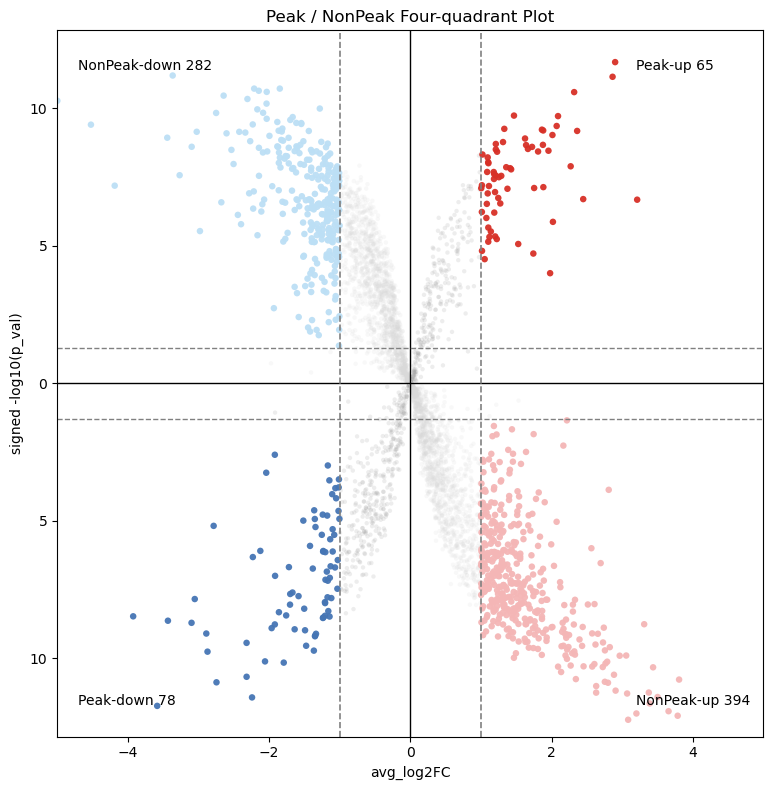

In [66]:
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
plot_signed_peak_volcano_final(
    result_df,
    output_png="signed_peak_volcano_final.pdf",
    figsize=(8, 8),
    fc_threshold=1,
    p_threshold=0.05
)

In [ ]:
display(result_df.head())